# Avocado Price — Data Cleaning & Feature Engineering

Pipeline:
1. Drop the leftover unnamed index column
2. Parse `Date` -> extract `month`, `week`
3. Rename PLU columns to readable names
4. Engineer `log_total_volume`, `log_total_bags`, `small_share`, `large_share`, `xl_share`
5. One-hot encode `type` (binary) and `region` (54 levels)
6. Save to `data/avocado_cleaned.csv`

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")
from utils import (load_data, drop_index_column, parse_date, rename_plu,
                   create_features, preprocess_data)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = load_data("data/avocado.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (18249, 14)


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


## 2. Missing / Invalid Values

In [3]:
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing values: 0
Duplicate rows: 0


## 3. Drop index, parse date, rename PLU columns

In [4]:
df_step = drop_index_column(df)
df_step = parse_date(df_step)
df_step = rename_plu(df_step)
print(f"Shape: {df_step.shape}")
print(f"New columns: {[c for c in df_step.columns if c not in df.columns]}")
df_step.head()

Shape: (18249, 15)
New columns: ['total_volume', 'small_hass', 'large_hass', 'xl_hass', 'total_bags', 'small_bags', 'large_bags', 'xl_bags', 'month', 'week']


,Date,AveragePrice,total_volume,small_hass,large_hass,xl_hass,total_bags,small_bags,large_bags,xl_bags,type,year,region,month,week
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12,52
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12,51
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12,50
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12,49
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11,48


## 4. Feature Engineering

In [5]:
df_feat = create_features(df_step)
new_cols = [c for c in df_feat.columns if c not in df_step.columns]
print(f"New features: {new_cols}")
df_feat[new_cols + ["AveragePrice"]].head()

New features: ['log_total_volume', 'log_total_bags', 'small_share', 'large_share', 'xl_share']


,log_total_volume,log_total_bags,small_share,large_share,xl_share,AveragePrice
0,11.070344,9.070833,0.018667,0.980466,0.000867,1.33
1,10.912867,9.159737,0.014861,0.983853,0.001286,1.35
2,11.680313,9.005325,0.007220,0.991595,0.001186,0.93
3,11.277116,8.667708,0.015468,0.983540,0.000992,1.08
4,10.840377,8.729874,0.020989,0.977321,0.001689,1.28


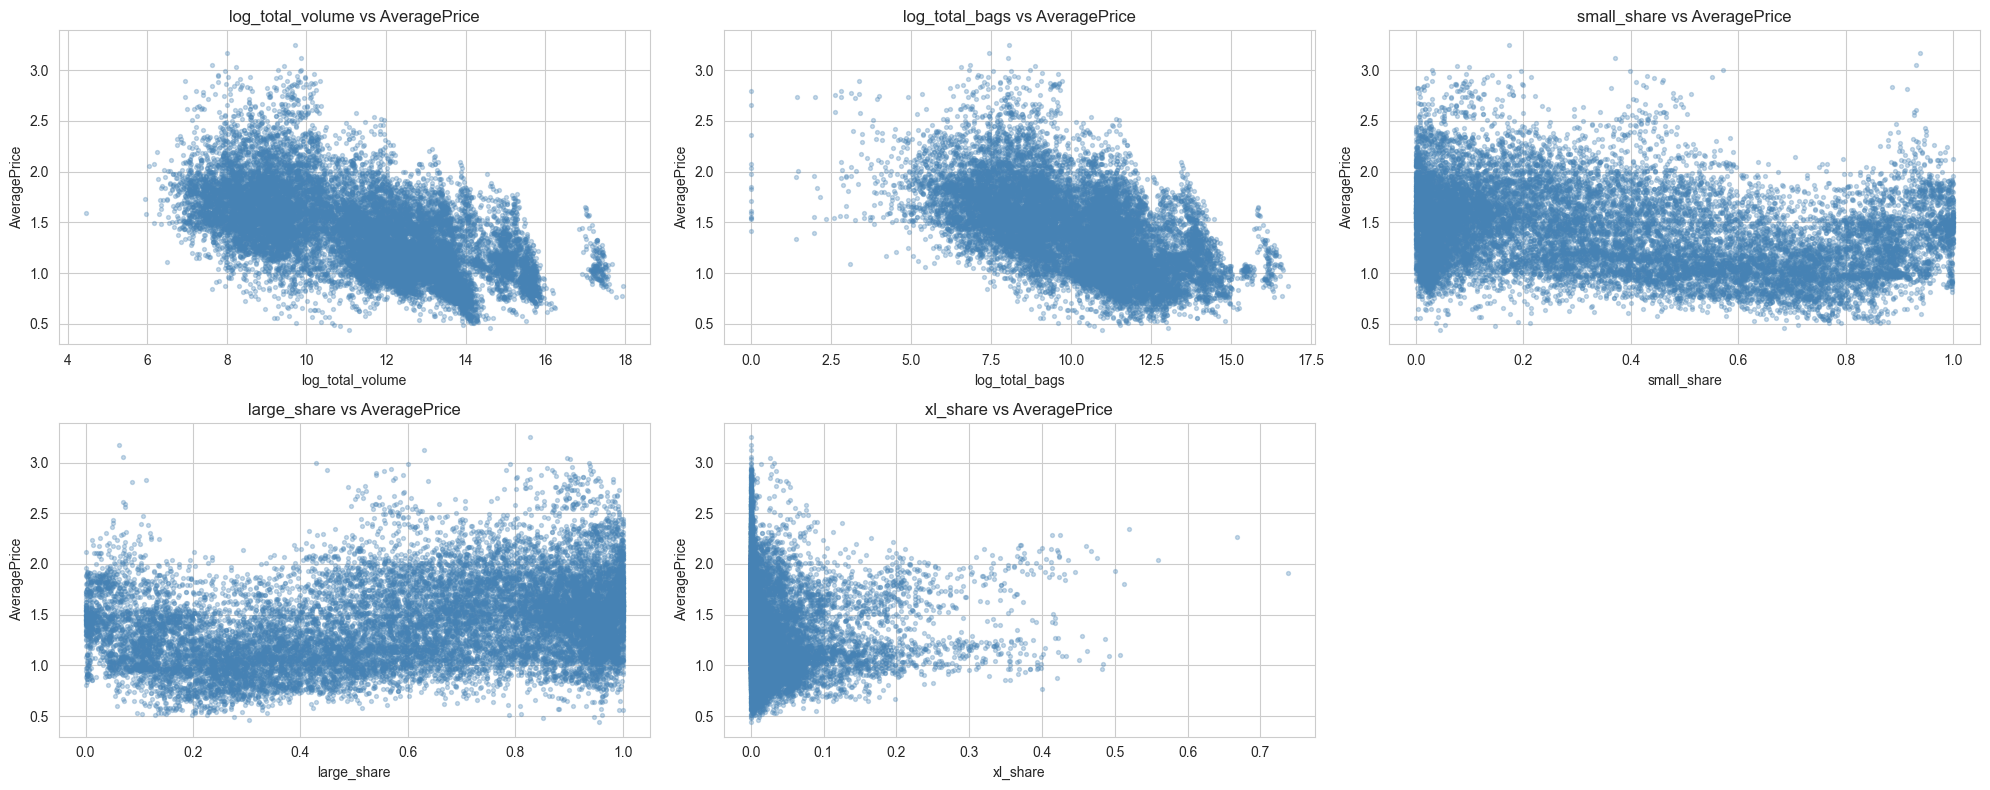

In [6]:
# Visualize transforms vs target
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
for i, col in enumerate(["log_total_volume","log_total_bags",
                         "small_share","large_share","xl_share"]):
    axes[i//3, i%3].scatter(df_feat[col], df_feat["AveragePrice"], alpha=0.3, color="steelblue", s=8)
    axes[i//3, i%3].set_xlabel(col); axes[i//3, i%3].set_ylabel("AveragePrice")
    axes[i//3, i%3].set_title(f"{col} vs AveragePrice")
axes[1, 2].axis("off")
plt.tight_layout(); plt.show()

## 5. Run the Full Pipeline

In [7]:
df_processed = preprocess_data(df)
print(f"Processed shape: {df_processed.shape}")
print(f"Missing values : {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape: (18249, 71)
Missing values : 0


,AveragePrice,total_volume,small_hass,large_hass,xl_hass,total_bags,small_bags,large_bags,xl_bags,year,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
1,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
2,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
3,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
4,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,2015,...,0,0,0,0,0,0,0,0,0,0


## 6. Sanity Checks & Save

In [8]:
assert df_processed.isnull().sum().sum() == 0
assert "AveragePrice" in df_processed.columns
print("All checks passed.")

All checks passed.


In [9]:
df_processed.to_csv("data/avocado_cleaned.csv", index=False)
print(f"Saved data/avocado_cleaned.csv ({df_processed.shape[0]} rows, {df_processed.shape[1]} cols)")

Saved data/avocado_cleaned.csv (18249 rows, 71 cols)
